In [1]:
# Imports & Load Data 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Data Folder path
DATA_PATH = r"C:\Users\alifa\OneDrive\Desktop\dissertation_project\data\MachineLearningCVE"

# List all CSV files found
csv_files = [f for f in os.listdir(DATA_PATH) if f.endswith('.csv')]
print(f"Found {len(csv_files)} CSV files:\n")
for f in csv_files:
    size = os.path.getsize(os.path.join(DATA_PATH, f)) / (1024*1024)
    print(f"  {f}  ({size:.1f} MB)")

Found 8 CSV files:

  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv  (73.6 MB)
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv  (73.3 MB)
  Friday-WorkingHours-Morning.pcap_ISCX.csv  (55.6 MB)
  Monday-WorkingHours.pcap_ISCX.csv  (168.7 MB)
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv  (79.3 MB)
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv  (49.6 MB)
  Tuesday-WorkingHours.pcap_ISCX.csv  (128.8 MB)
  Wednesday-workingHours.pcap_ISCX.csv  (214.7 MB)


In [2]:
# Load & Combine All CSV Files 
print("Loading CSV files...\n")

dfs = []
for f in csv_files:
    filepath = os.path.join(DATA_PATH, f)
    df_temp = pd.read_csv(filepath, encoding='utf-8', low_memory=False)
    # Strip whitespace from column names
    df_temp.columns = df_temp.columns.str.strip()
    print(f"  Loaded: {f}")
    print(f"    Rows: {len(df_temp):,}  |  Columns: {len(df_temp.columns)}")
    dfs.append(df_temp)

# Combine all into one master dataframe
df = pd.concat(dfs, ignore_index=True)

print(f"\n{'='*50}")
print(f"MASTER DATASET LOADED")
print(f"{'='*50}")
print(f"Total rows    : {len(df):,}")
print(f"Total columns : {len(df.columns)}")
print(f"Memory usage  : {df.memory_usage(deep=True).sum() / (1024**2):.1f} MB")
print(f"{'='*50}")

Loading CSV files...

  Loaded: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
    Rows: 225,745  |  Columns: 79
  Loaded: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
    Rows: 286,467  |  Columns: 79
  Loaded: Friday-WorkingHours-Morning.pcap_ISCX.csv
    Rows: 191,033  |  Columns: 79
  Loaded: Monday-WorkingHours.pcap_ISCX.csv
    Rows: 529,918  |  Columns: 79
  Loaded: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
    Rows: 288,602  |  Columns: 79
  Loaded: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
    Rows: 170,366  |  Columns: 79
  Loaded: Tuesday-WorkingHours.pcap_ISCX.csv
    Rows: 445,909  |  Columns: 79
  Loaded: Wednesday-workingHours.pcap_ISCX.csv
    Rows: 692,703  |  Columns: 79

MASTER DATASET LOADED
Total rows    : 2,830,743
Total columns : 79
Memory usage  : 1855.5 MB


In [4]:
# Label Distribution 
print("Attack label distribution:\n")
label_counts = df[' Label'].value_counts()
label_pcts   = df[' Label'].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    'Count'      : label_counts,
    'Percentage' : label_pcts.round(2)
})
print(summary.to_string())

print(f"\nTotal unique labels: {df[' Label'].nunique()}")

Attack label distribution:



KeyError: ' Label'

In [5]:
# Check exact column names 
print("All column names in the dataset:\n")
for col in df.columns:
    print(repr(col))

All column names in the dataset:

'Destination Port'
'Flow Duration'
'Total Fwd Packets'
'Total Backward Packets'
'Total Length of Fwd Packets'
'Total Length of Bwd Packets'
'Fwd Packet Length Max'
'Fwd Packet Length Min'
'Fwd Packet Length Mean'
'Fwd Packet Length Std'
'Bwd Packet Length Max'
'Bwd Packet Length Min'
'Bwd Packet Length Mean'
'Bwd Packet Length Std'
'Flow Bytes/s'
'Flow Packets/s'
'Flow IAT Mean'
'Flow IAT Std'
'Flow IAT Max'
'Flow IAT Min'
'Fwd IAT Total'
'Fwd IAT Mean'
'Fwd IAT Std'
'Fwd IAT Max'
'Fwd IAT Min'
'Bwd IAT Total'
'Bwd IAT Mean'
'Bwd IAT Std'
'Bwd IAT Max'
'Bwd IAT Min'
'Fwd PSH Flags'
'Bwd PSH Flags'
'Fwd URG Flags'
'Bwd URG Flags'
'Fwd Header Length'
'Bwd Header Length'
'Fwd Packets/s'
'Bwd Packets/s'
'Min Packet Length'
'Max Packet Length'
'Packet Length Mean'
'Packet Length Std'
'Packet Length Variance'
'FIN Flag Count'
'SYN Flag Count'
'RST Flag Count'
'PSH Flag Count'
'ACK Flag Count'
'URG Flag Count'
'CWE Flag Count'
'ECE Flag Count'
'Down/Up Ratio'

In [3]:
# Label Distribution
print("Attack label distribution:\n")
label_counts = df['Label'].value_counts()
label_pcts   = df['Label'].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    'Count'      : label_counts,
    'Percentage' : label_pcts.round(2)
})
print(summary.to_string())
print(f"\nTotal unique labels: {df['Label'].nunique()}")

Attack label distribution:

                              Count  Percentage
Label                                          
BENIGN                      2273097       80.30
DoS Hulk                     231073        8.16
PortScan                     158930        5.61
DDoS                         128027        4.52
DoS GoldenEye                 10293        0.36
FTP-Patator                    7938        0.28
SSH-Patator                    5897        0.21
DoS slowloris                  5796        0.20
DoS Slowhttptest               5499        0.19
Bot                            1966        0.07
Web Attack � Brute Force       1507        0.05
Web Attack � XSS                652        0.02
Infiltration                     36        0.00
Web Attack � Sql Injection       21        0.00
Heartbleed                       11        0.00

Total unique labels: 15


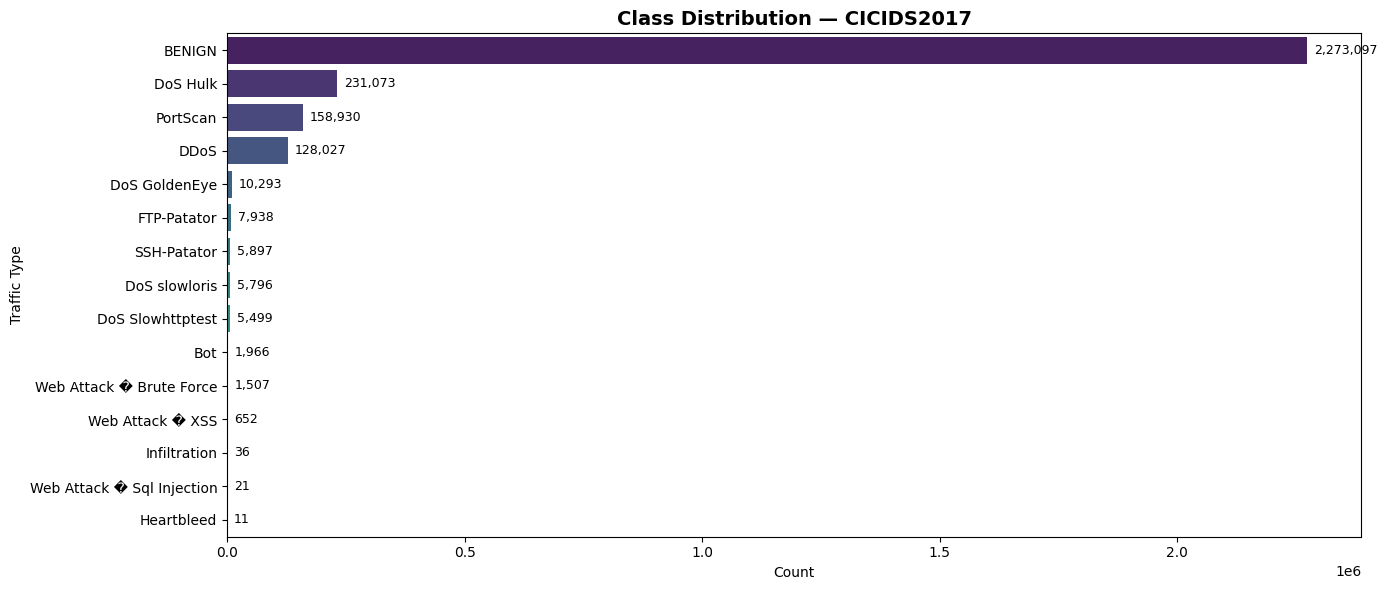

Plot saved to results folder


In [4]:
# Class Distribution Plot 
plt.figure(figsize=(14, 6))
ax = sns.countplot(
    data=df,
    y='Label',
    order=df['Label'].value_counts().index,
    palette='viridis'
)
plt.title('Class Distribution — CICIDS2017', fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Traffic Type')

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_width()):,}',
        (p.get_width(), p.get_y() + p.get_height() / 2),
        ha='left', va='center', fontsize=9, xytext=(5, 0),
        textcoords='offset points'
    )

plt.tight_layout()
plt.savefig(r"C:\Users\alifa\OneDrive\Desktop\dissertation_project\results\class_distribution.png", dpi=150)
plt.show()
print("Plot saved to results folder")

In [5]:
#  Data Quality Check 
print("DATA QUALITY REPORT")
print("=" * 50)

# Missing values
null_counts = df.isnull().sum()
null_cols = null_counts[null_counts > 0]
print(f"\nColumns with missing values: {len(null_cols)}")
if len(null_cols) > 0:
    print(null_cols)
else:
    print("  None found")

# Infinite values
numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_counts = np.isinf(df[numeric_cols]).sum()
inf_cols = inf_counts[inf_counts > 0]
print(f"\nColumns with infinite values: {len(inf_cols)}")
if len(inf_cols) > 0:
    print(inf_cols)
else:
    print("  None found")

# Duplicate rows
dupes = df.duplicated().sum()
print(f"\nDuplicate rows: {dupes:,}")

# Data types
print(f"\nData types summary:")
print(df.dtypes.value_counts())

print("\n" + "=" * 50)
print("Data quality check complete")
print("=" * 50)

DATA QUALITY REPORT

Columns with missing values: 1
Flow Bytes/s    1358
dtype: int64

Columns with infinite values: 2
Flow Bytes/s      1509
Flow Packets/s    2867
dtype: int64

Duplicate rows: 308,381

Data types summary:
int64      54
float64    24
object      1
Name: count, dtype: int64

Data quality check complete


In [6]:
# Statistical Summary 
print("Statistical summary of numeric features:\n")
stats = df.select_dtypes(include=[np.number]).describe().T
stats['cv'] = (stats['std'] / stats['mean']).round(3)  # coefficient of variation
print(stats[['min', 'max', 'mean', 'std', 'cv']].to_string())
print(f"\nTotal numeric features: {len(stats)}")

Statistical summary of numeric features:

                                      min           max          mean           std       cv
Destination Port             0.000000e+00  6.553500e+04  8.071483e+03  1.828363e+04    2.265
Flow Duration               -1.300000e+01  1.200000e+08  1.478566e+07  3.365374e+07    2.276
Total Fwd Packets            1.000000e+00  2.197590e+05  9.361160e+00  7.496728e+02   80.083
Total Backward Packets       0.000000e+00  2.919220e+05  1.039377e+01  9.973883e+02   95.960
Total Length of Fwd Packets  0.000000e+00  1.290000e+07  5.493024e+02  9.993589e+03   18.193
Total Length of Bwd Packets  0.000000e+00  6.554530e+08  1.616264e+04  2.263088e+06  140.020
Fwd Packet Length Max        0.000000e+00  2.482000e+04  2.075999e+02  7.171848e+02    3.455
Fwd Packet Length Min        0.000000e+00  2.325000e+03  1.871366e+01  6.033935e+01    3.224
Fwd Packet Length Mean       0.000000e+00  5.940857e+03  5.820194e+01  1.860912e+02    3.197
Fwd Packet Length Std       